<a href="https://colab.research.google.com/github/Fauzi455/PembelajaranMesin_2026/blob/main/JS-04/TUGAS/Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tugas Lab

In [54]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [63]:
#baca data dari file CSV
data = pd.read_csv('insurance.csv')
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


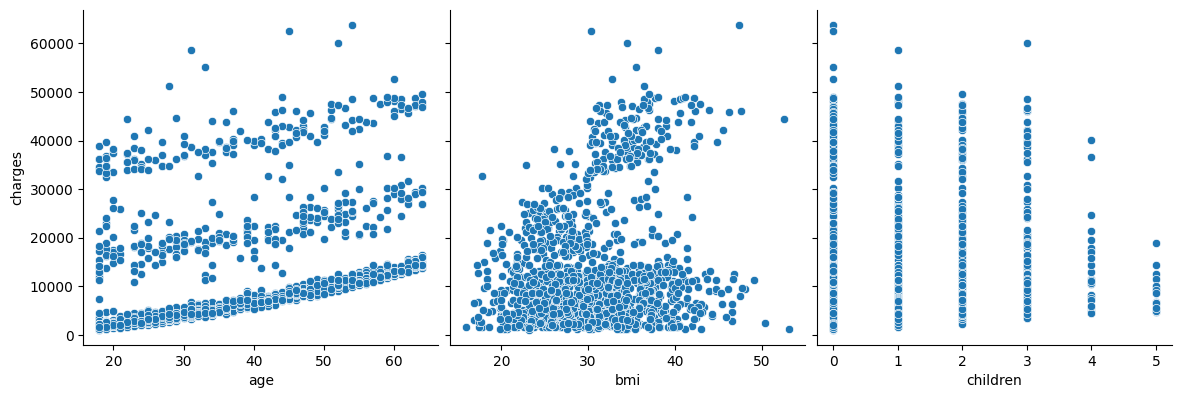

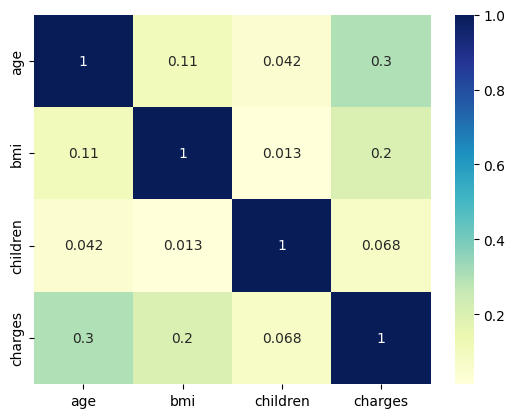

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

#visualisasi data dengan pairplot (Scatter Plot)
sns.pairplot(data, x_vars=['age', 'bmi', 'children'],
    y_vars='charges', height=4, aspect=1, kind='scatter')
plt.show()

#visualisasi korelasi dengan heatmap
sns.heatmap(data.corr(numeric_only=True), cmap='YlGnBu', annot=True)
plt.show()

1. Identifikasi variabel-variabel yang akan digunakan sebagai variabel bebas (fitur) dan variabel target (biaya medis personal).

In [75]:
#variabel target
target = "charges"

#variabel fitur
X = data.drop(columns=[target])
y = data[target]

print("Variabel fitur:")
print(X.columns.tolist())

print("\nVariabel target:")
print(target)

Variabel fitur:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Variabel target:
charges


2. Bagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi yang sesuai.

In [77]:
#pembagian data latih dan data uji dengan proporsi 7:3
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)
print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data training: 936
Jumlah data testing : 402



3. Lakukan feature scaling jika diperlukan.

In [83]:
#pisahkan fitur dan target
X = data.drop("charges", axis=1)
y = data["charges"]

#encoding data kategorikal
X = pd.get_dummies(X, drop_first=True)

#Feature Scaling
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()

X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.values.reshape(-1, 1))

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (1338, 8)
Shape y: (1338, 1)


4. Buat model multiple linear regression menggunakan Scikit-Learn.

In [113]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=100)

#buat model Multiple Linear Regression
regressor = LinearRegression()

#latih model menggunakan data training yang sudah di-scaled
regressor.fit(X_train_scaled, y_train_scaled.ravel())

#menampilkan koefisien
if hasattr(X, "columns"):
    features = X.columns
else:
    features = [f"Fitur {i+1}" for i in range(len(regressor.coef_))]

coef_df = pd.DataFrame({"Fitur": features, "Koefisien": regressor.coef_})

print("Koefisien model:")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {regressor.intercept_:.4f}")

Koefisien model:
  Fitur  Koefisien
Fitur 1   0.301678
Fitur 2   0.145881
Fitur 3   0.047028
Fitur 4  -0.000003
Fitur 5   0.799731
Fitur 6  -0.026760
Fitur 7  -0.034607
Fitur 8  -0.056740

Intercept: 0.0124


5. Latih model pada data latih dan lakukan prediksi pada data uji.

In [118]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=100)

#buat model Multiple Linear Regression
regressor = LinearRegression()

#latih model menggunakan data training yang sudah di-scaled
regressor.fit(X_train_scaled, y_train_scaled.ravel())

#lakukan prediksi pada data test yang sudah di-scaled
y_pred_scaled = regressor.predict(X_test_scaled)

#evaluasi model menggunakan R-squared score pada data test
r_squared_test = r2_score(y_test_scaled, y_pred_scaled)
print(f"R-squared score pada data uji: {r_squared_test:.4f}")


R-squared score pada data uji: 0.7772


6. Evaluasi model dengan menghitung metrik seperti R-squared, MSE, dan MAE. Tampilkan hasil evaluasi.

In [120]:
#evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y
y_pred = regressor.predict(X)

#menghitung MAE
mae = mean_absolute_error(y_actual, y_pred)

#menghitung MSE
mse = mean_squared_error(y_actual, y_pred)

#menghitung RMSE
rmse = np.sqrt(mse)

#menghitung R-squared
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 0.34252885531915667
MSE: 0.2503742659624521
RMSE: 0.5003741259921941
R-squared: 0.7496257340375478


7. Ulangi langkah 4 dengan menggunakan model SVR. Anda dapat bereksperimen dengan dengan melakukan *hyperparameter tunning*

In [124]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#pastikan y_train_scaled dan y_test_scaled adalah 1D array untuk SVR
y_train_scaled_1d = y_train_scaled.ravel()
y_test_scaled_1d = y_test_scaled.ravel()

#inisialisasi model SVR
svr = SVR()

#definisikan parameter grid untuk hyperparameter tuning
param_grid = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2]
}

#lakukan GridSearchCV untuk mencari hyperparameter terbaik
grid_search = GridSearchCV(estimator=svr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train_scaled_1d)

#dapatkan parameter terbaik
best_params = grid_search.best_params_
print(f"Parameter terbaik untuk SVR: {best_params}")

# latih model SVR dengan parameter terbaik
svr_best = SVR(**best_params)
svr_best.fit(X_train_scaled, y_train_scaled_1d)

#lakukan prediksi pada data test yang sudah di-scaled
y_pred_svr_scaled = svr_best.predict(X_test_scaled)

#evaluasi model SVR
mae_svr = mean_absolute_error(y_test_scaled_1d, y_pred_svr_scaled)
mse_svr = mean_squared_error(y_test_scaled_1d, y_pred_svr_scaled)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test_scaled_1d, y_pred_svr_scaled)

print("\n--- Evaluasi Model SVR (dengan Hyperparameter Tuning) ---")
print(f"Mean Absolute Error (MAE) SVR: {mae_svr:.4f}")
print(f"Mean Squared Error (MSE) SVR: {mse_svr:.4f}")
print(f"Root Mean Squared Error (RMSE) SVR: {rmse_svr:.4f}")
print(f"R-squared (R2) SVR: {r2_svr:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Parameter terbaik untuk SVR: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}

--- Evaluasi Model SVR (dengan Hyperparameter Tuning) ---
Mean Absolute Error (MAE) SVR: 0.2132
Mean Squared Error (MSE) SVR: 0.1386
Root Mean Squared Error (RMSE) SVR: 0.3724
R-squared (R2) SVR: 0.8601
